# 1 — Exploratory Data Analysis
**Dataset:** Pima Indians Diabetes — 768 samples, 8 features, binary target (`Outcome`)

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Dataset Overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


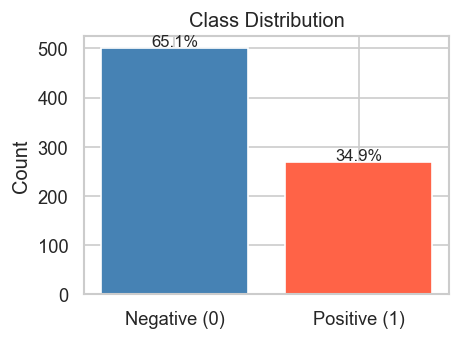

In [4]:
counts = df['Outcome'].value_counts().sort_index()
labels = {0: 'Negative (0)', 1: 'Positive (1)'}
pct = (counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar([labels[i] for i in counts.index], counts.values, color=['steelblue', 'tomato'])
ax.set_ylabel('Count')
ax.set_title('Class Distribution')
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c + 5, f'{p}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 3. Missing Value Analysis
Five columns use `0` as a placeholder for missing values where zero is biologically impossible.
`Pregnancies` (can be 0) and `Age` (minimum is 21 in this dataset) are left untouched.

In [5]:
ZERO_AS_NAN = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

missing = pd.DataFrame({
    'zero_count': [(df[c] == 0).sum() for c in ZERO_AS_NAN],
    'zero_pct':   [(df[c] == 0).mean() * 100 for c in ZERO_AS_NAN]
}, index=ZERO_AS_NAN).round(1).sort_values('zero_pct', ascending=False)

print(missing)

               zero_count  zero_pct
Insulin               374      48.7
SkinThickness         227      29.6
BloodPressure          35       4.6
BMI                    11       1.4
Glucose                 5       0.7


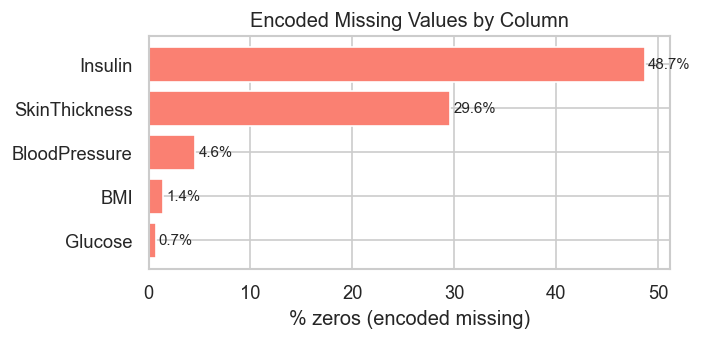

In [6]:
df_clean = df.copy()
df_clean[ZERO_AS_NAN] = df_clean[ZERO_AS_NAN].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(6, 3))
sorted_missing = missing.sort_values('zero_pct')
ax.barh(sorted_missing.index, sorted_missing['zero_pct'], color='salmon')
ax.set_xlabel('% zeros (encoded missing)')
ax.set_title('Encoded Missing Values by Column')
for i, v in enumerate(sorted_missing['zero_pct']):
    ax.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [7]:
# Per-class medians for columns with missingness — informs imputation strategy
df_clean.groupby('Outcome')[ZERO_AS_NAN].median().round(2)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
Outcome,,,,,
0,107.0,70.0,27.0,102.5,30.1
1,140.0,74.5,32.0,169.5,34.3


## 4. Univariate Distributions

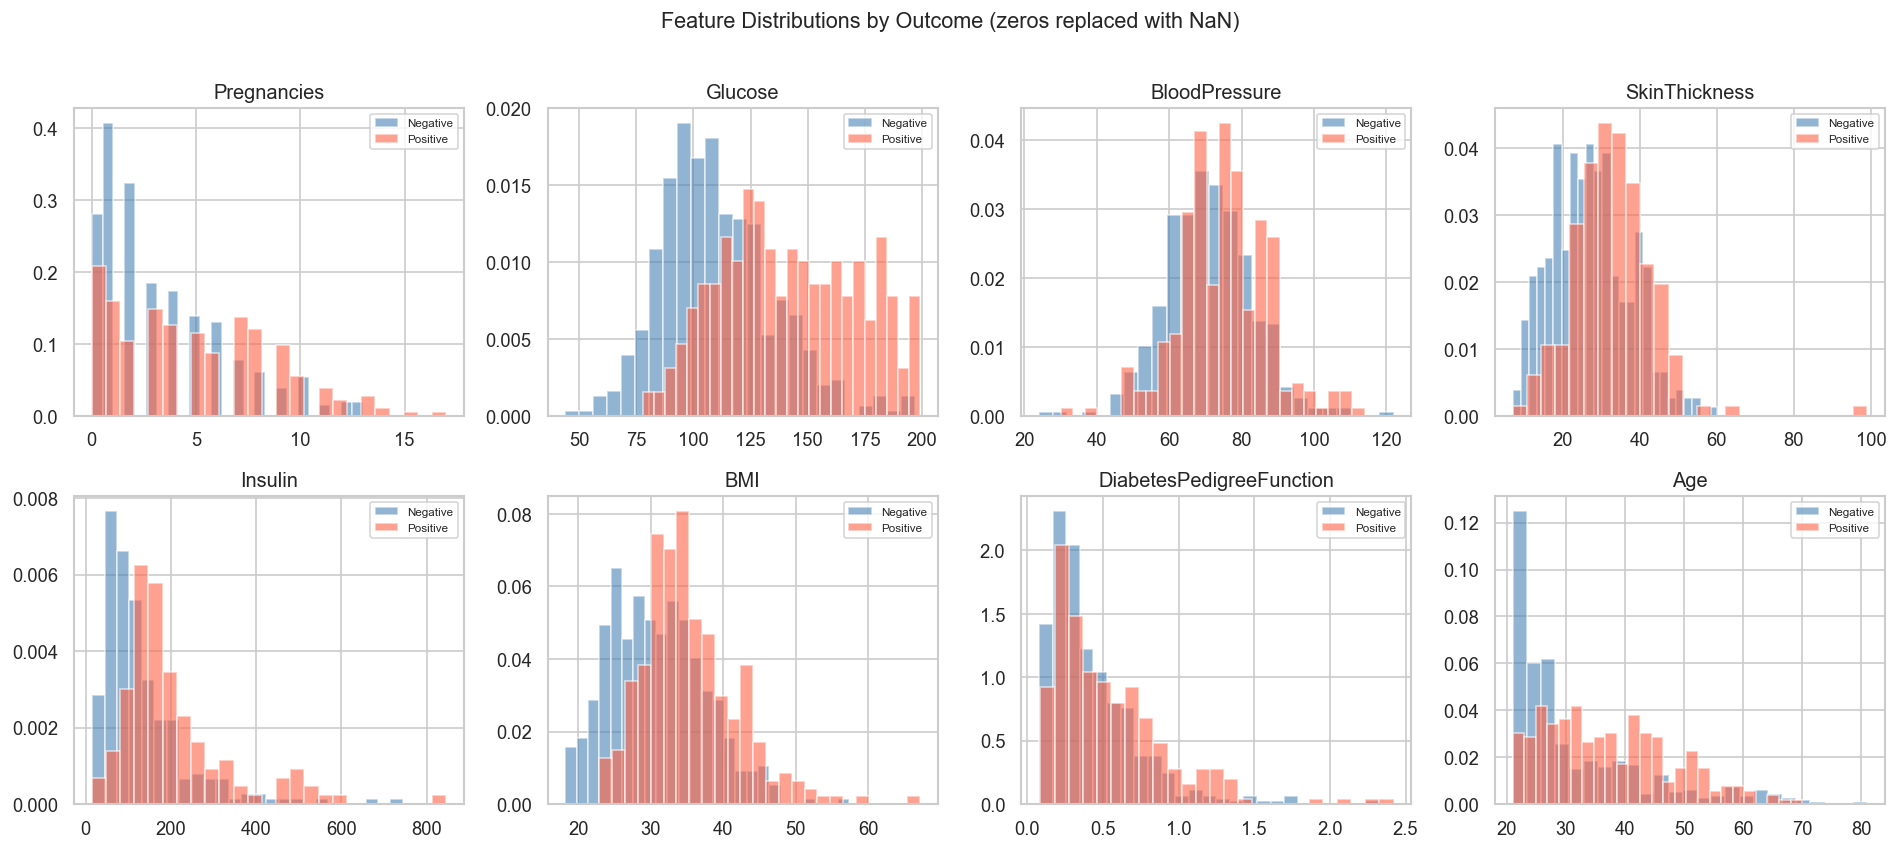

In [8]:
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in [(0, 'steelblue', 'Negative'), (1, 'tomato', 'Positive')]:
        vals = df_clean.loc[df_clean['Outcome'] == outcome, col].dropna()
        axes[i].hist(vals, bins=25, alpha=0.6, color=color, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Outcome (zeros replaced with NaN)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
skew = df_clean[features].skew().round(2).sort_values(ascending=False)
print('Skewness:')
print(skew)

Skewness:
Insulin                     2.17
DiabetesPedigreeFunction    1.92
Age                         1.13
Pregnancies                 0.90
SkinThickness               0.69
BMI                         0.59
Glucose                     0.53
BloodPressure               0.13
dtype: float64


## 5. Correlation & Bivariate Analysis

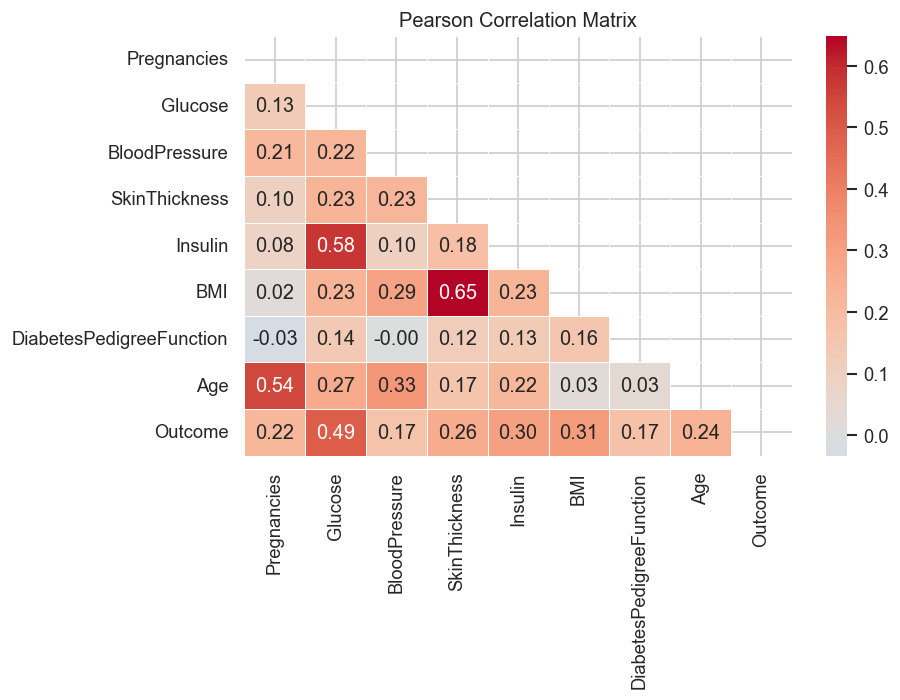

In [10]:
corr = df_clean.corr(numeric_only=True)
mask = np.triu(np.ones(corr.shape, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5, ax=ax
)
ax.set_title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

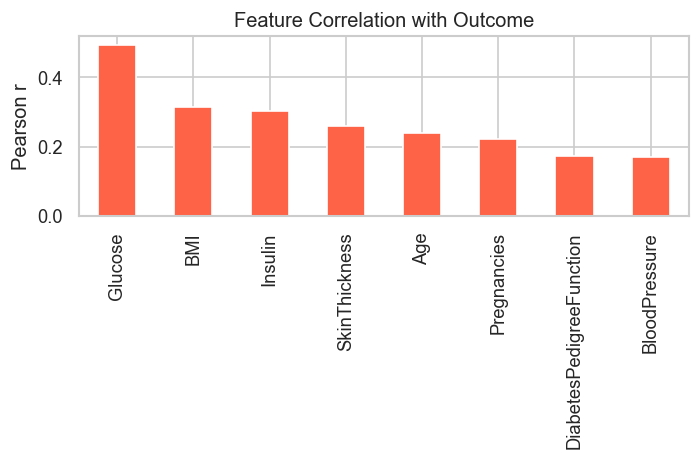

In [11]:
target_corr = corr['Outcome'].drop('Outcome').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Outcome')
ax.set_ylabel('Pearson r')
plt.tight_layout()
plt.show()

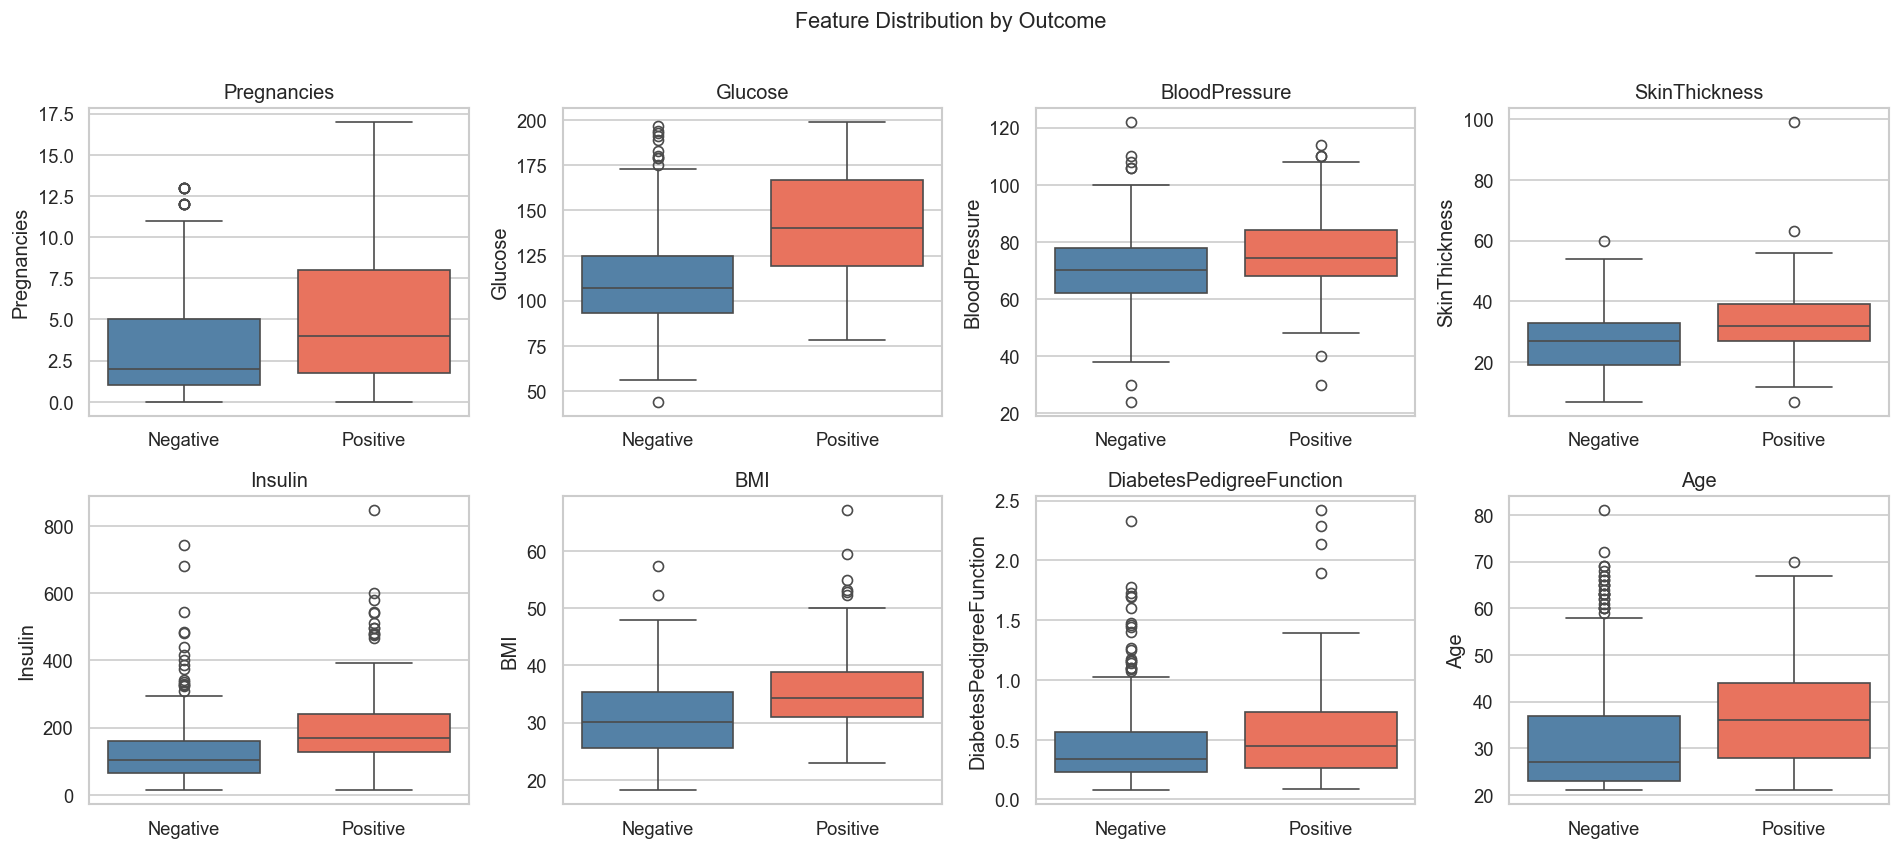

In [12]:
df_plot = df_clean.copy()
df_plot['Outcome'] = df_plot['Outcome'].map({0: 'Negative', 1: 'Positive'})

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        data=df_plot, x='Outcome', y=col,
        hue='Outcome',
        palette={'Negative': 'steelblue', 'Positive': 'tomato'},
        order=['Negative', 'Positive'],
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distribution by Outcome', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 6. Outlier Detection (IQR method)

In [13]:
def iqr_outliers(series):
    s = series.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    return pd.Series({'outlier_count': n_out, 'outlier_pct': round(n_out / len(s) * 100, 1),
                      'lower_fence': round(lo, 2), 'upper_fence': round(hi, 2)})

outlier_df = df_clean[features].apply(iqr_outliers).T.sort_values('outlier_count', ascending=False)
print(outlier_df)

                          outlier_count  outlier_pct  lower_fence  upper_fence
DiabetesPedigreeFunction           29.0          3.8        -0.33         1.20
Insulin                            24.0          6.1       -94.38       360.62
BloodPressure                      14.0          1.9        40.00       104.00
Age                                 9.0          1.2        -1.50        66.50
BMI                                 8.0          1.1        13.85        50.25
Pregnancies                         4.0          0.5        -6.50        13.50
SkinThickness                       3.0          0.6         1.00        57.00
Glucose                             0.0          0.0        36.00       204.00


## 7. Preprocessing Decisions

All decisions below are derived from the EDA output above.

---

### 7.1 Missing Value Imputation

| Column | Missing % | Class medians (0 / 1) | Strategy | Reason |
|---|---|---|---|---|
| Insulin | 48.7% | 102.5 / 169.5 | **Median per class** | Near-half the data is missing; class medians differ by 65 units — overall median would bias imputed values |
| SkinThickness | 29.6% | 27.0 / 32.0 | **Median per class** | High missingness; class medians differ — class-conditional imputation preserves signal |
| BloodPressure | 4.6% | 70.0 / 74.5 | **Overall median** | Low missingness; class medians differ by only 4.5 — class conditioning adds little value |
| BMI | 1.4% | 30.1 / 34.3 | **Overall median** | Very few missing; straightforward fill |
| Glucose | 0.7% | — | **Overall median** | Only 5 missing values; strongest predictor (r=0.495) — conservative imputation avoids distortion |

---

### 7.2 Transformations

Based on skewness values:

| Column | Skew | Action |
|---|---|---|
| Insulin | 2.17 | `log1p` — heavy right tail confirmed in histogram |
| DiabetesPedigreeFunction | 1.92 | `log1p` — also has 29 IQR outliers; transform reduces their leverage |
| Age | 1.13 | Leave as-is — moderate skew, distributions by class are clearly separated; binning considered but deferred |
| Pregnancies | 0.90 | Leave as-is — discrete integer; skew is acceptable |
| SkinThickness, BMI, Glucose | 0.53–0.69 | No transform needed — near-symmetric after NaN correction |
| BloodPressure | 0.13 | No transform needed — nearly symmetric |

---

### 7.3 Outliers

**Do not drop.** Dataset has only 768 rows; outliers are likely clinically real values (e.g. high pedigree function, high insulin). The `log1p` transforms on Insulin and DiabetesPedigreeFunction will reduce their influence for linear models. Tree models are inherently robust.

---

### 7.4 Scaling

Apply `StandardScaler` fitted on train split only. Applied only for models sensitive to scale (logistic regression, SVM, KNN). Tree-based models (Random Forest, XGBoost) skip this step.

---

### 7.5 Class Imbalance

65.1% Negative / 34.9% Positive — moderate imbalance. Strategy:
- Use `class_weight='balanced'` in all sklearn estimators as default.
- Evaluate with **F1-score** and **ROC-AUC** — not accuracy alone.
- SMOTE deferred until after baseline is established.

---

### 7.6 Train / Validation / Test Split

**70 / 15 / 15** stratified on `Outcome`. `random_state=42` fixed throughout.